In [1]:
import numpy as np
import json
import gc
import torch
from PIL import Image
import os
import math

### CP METHODS SCORE GENERATION

#### Utils

In [2]:
def get_image_dims(img_path: str) -> tuple[int, int]:
    """Read image dimensions from file header without loading pixels."""
    with Image.open(img_path) as img:
        return img.size  # (width, height)

def xy_to_index(x, y, orig_w, orig_h, level, patch_size=16):
    """
    Convert pixel coordinate (x, y) to flat index in the embedding tensor.
    This is required to compare the final results and get the embeddings corresponding to
    a coordinate.
    
    Args:
        x, y: fPixel coordinates in the original image.
        orig_w, orig_h: Original image dimensions.
        level: "patch" or "pixel".
        patch_size: ViT patch size (only used for patch level).

    Returns:
        Flat index into the (K, D) embedding tensor.
    """
    if level == "pixel":
        return x * orig_h + y
    else:
        grid_cols = math.ceil(orig_w / patch_size)
        return (y // patch_size) * grid_cols + (x // patch_size)

In [3]:
def remove_self_3d(tensor: np.ndarray) -> np.ndarray:
    """
    Remove self-scores from the diagonal of an (N, N, K) calibration tensor.

    Extends remove_self_2d to the all-label case where each (i, j) entry
    contains K candidate scores rather than a single true-label score.

    Args:
        tensor: (N, N, K) array.

    Returns:
        (N, N-1, K) array with the diagonal slices removed.
    """
    N = tensor.shape[0]
    mask = ~np.eye(N, dtype=bool)
    # mask is (N, N), broadcast over K dimension
    return tensor[mask].reshape(N, N - 1, tensor.shape[2])

In [4]:
def scores_to_matrix(score_list, pad_value=1.1):
    M = len(score_list)
    N = score_list[0].shape[1]
    K_max = max(s.shape[0] for s in score_list)
    matrix = np.full((N, M, K_max), pad_value)
    for m in range(M):
        K_m = score_list[m].shape[0]
        matrix[:, m, :K_m] = score_list[m].T
    return matrix

In [5]:
def get_landmark_indices(landmarks, image_dims, level, patch_size=16):
    indices = []
    for lm, (w, h) in zip(landmarks, image_dims):
        x, y = int(lm[0]), int(lm[1])
        indices.append(xy_to_index(x, y, w, h, level, patch_size))
    return indices


#### Load non-conformity scores

In [6]:
def load_data(parent_folder="data/"):
    img_folder = os.path.join(parent_folder, DATASET_ID, "images")
    score_folder = os.path.join(parent_folder, DATASET_ID, "scores")

    # Load JSONs
    with open(os.path.join(img_folder, "train_annotations.json"), "r") as f:
        calib_json = json.load(f)
    with open(os.path.join(img_folder, "test_annotations.json"), "r") as f:
        test_json = json.load(f)

    # Load cached cosine scores
    calib_score_file = f"{DATASET_ID}_calib_cosines_{LEVEL}_ps{PATCH_SIZE}_lm{LMS_IDX}.pt"
    test_score_file = f"{DATASET_ID}_eval_cosines_{LEVEL}_ps{PATCH_SIZE}_lm{LMS_IDX}.pt"

    raw_calib_scores = torch.load(os.path.join(score_folder, calib_score_file), weights_only=False)
    raw_test_scores = torch.load(os.path.join(score_folder, test_score_file), weights_only=False)

    return {
        "calib_json": calib_json,
        "test_json": test_json,
        "calib_scores": raw_calib_scores,
        "test_scores": raw_test_scores,
    }

#### Apply Softmax

In [7]:
def apply_softmax_calib(calib_cosines: dict, temperature: float = 0.05, apply_softmax: bool = True,
                        return_all_scores: bool = False) -> np.ndarray | tuple[np.ndarray, np.ndarray]:
        """
        Convert raw calibration cosines into nonconformity scores.
 
        Applies self-masking, optional temperature scaling + softmax, and
        extracts true-label scores.
 
        Args:
            calib_cosines: Dict from compute_calib_cosines.
            temperature: Softmax temperature.
            apply_softmax: Whether to apply softmax normalization.
            return_all_scores: If True, also return (N, N, K_max) all-candidate scores.
 
        Returns:
            calib_true_matrix: (N, N) with diagonal = inf.
            calib_all_matrix (if return_all_scores): (N, N, K_max) with diagonal = inf.
        """
        cosines_list = calib_cosines["cosines"]
        gt_indices = calib_cosines["gt_indices"]
        N = len(cosines_list)
 
        if not apply_softmax:
            # Without softmax: extract only landmark-to-landmark scores
            # cosines_list[j][i, gt_indices[j]] = cosine(source_i, true_label_j)
            calib_true = np.empty((N, N), dtype=np.float64)
            for j in range(N):
                calib_true[:, j] = 1.0 - cosines_list[j][:, gt_indices[j]]
            calib_true[np.arange(N), np.arange(N)] = np.inf
            if return_all_scores:
                raise NotImplementedError(
                    "return_all_scores requires apply_softmax=True."
                )
            return calib_true
 
        # With softmax
        calib_true = np.empty((N, N), dtype=np.float64)
        calib_all_list = [] if return_all_scores else None
 
        for j in range(N):
            cos = torch.from_numpy(cosines_list[j])  # (N, K_j)
            cos[j, :] = torch.finfo(cos.dtype).min     # mask self
            probs = torch.softmax(cos / temperature, dim=1)
            scores = 1.0 - probs  # (N, K_j)
 
            calib_true[:, j] = scores[:, gt_indices[j]].numpy()
 
            if return_all_scores:
                calib_all_list.append(scores.numpy())
 
            del cos, probs, scores
 
        np.fill_diagonal(calib_true, np.inf)
 
        if not return_all_scores:
            return calib_true
        K_max = max(arr.shape[1] for arr in calib_all_list)
        calib_all_matrix = np.full((N, N, K_max), 1.1)
        for j, scores_j in enumerate(calib_all_list):
            K_j = scores_j.shape[1]
            calib_all_matrix[:, j, :K_j] = scores_j
        for i in range(N):
            calib_all_matrix[i, i, :] = np.inf
 
        del calib_all_list
        gc.collect()
 
        return calib_true, calib_all_matrix

In [8]:
def apply_softmax_eval(eval_cosines: dict, temperature: float = 0.05, apply_softmax: bool = True) -> list[np.ndarray]:
        """
        Convert raw evaluation cosines into nonconformity scores.
 
        Args:
            eval_cosines: Dict from compute_eval_cosines.
            temperature: Softmax temperature.
            apply_softmax: Whether to apply softmax normalization.
 
        Returns:
            List of M arrays, each (K_m, N).
        """
        cosines_list = eval_cosines["cosines"]
        all_scores = []
 
        for cos_np in cosines_list:
            cos = torch.from_numpy(cos_np)  # (N, K_m)
 
            if apply_softmax:
                cos = torch.softmax(cos / temperature, dim=1)
 
            scores = 1.0 - cos
            all_scores.append(scores.T.numpy())  # (K_m, N)
            del cos
 
        return all_scores

#### Harmonize Scores 
- For calibration K and evaluation K can be different, but current implementation of cp methods assumes them to be same, so we need to harmonize it. CAOS/SCOS doesn't require it.

In [9]:
def harmonize_scores(calib_all_matrix, eval_scores_matrix):
    K_calib = calib_all_matrix.shape[2]
    K_eval = eval_scores_matrix.shape[2]
    if K_calib != K_eval:
        K_unified = max(K_calib, K_eval)
        print(f"Harmonizing K: calib={K_calib}, eval={K_eval} -> {K_unified}")
        if K_calib < K_unified:
            calib_all_matrix = np.pad(
                calib_all_matrix,
                ((0, 0), (0, 0), (0, K_unified - K_calib)),
                constant_values=1.1,
            )
        if K_eval < K_unified:
            eval_scores_matrix = np.pad(
                eval_scores_matrix,
                ((0, 0), (0, 0), (0, K_unified - K_eval)),
                constant_values=1.1,
            )
    
    calib_all_no_self = remove_self_3d(calib_all_matrix)
    return calib_all_no_self, eval_scores_matrix
    

#### Apply cp methods
- Note : Currently not supporting fullcaos as it require reverse scores

In [81]:
DATASET_ID = "aeroplane_pascal"
LEVEL = "patch"
LMS_IDX = 2
PATCH_SIZE=16

In [82]:
BASE_IMG_PATH = "data/aeroplane_pascal/images/"  # adjust as needed
TEMPERATURE = 0.05
ALPHA = 0.1
K = 3  # for CAOS

##### 1. Data and Scores Loading

In [83]:
data = load_data()
calib_img_paths = [os.path.join(BASE_IMG_PATH, x["img_path"]) for x in data["calib_json"]]
test_img_paths = [os.path.join(BASE_IMG_PATH, x["img_path"]) for x in data["test_json"]]

calib_lms = [entry["landmarks"][LMS_IDX] for entry in data["calib_json"]]
test_lms = [entry["landmarks"][LMS_IDX] for entry in data["test_json"]]

N = len(calib_img_paths)
M = len(test_img_paths)
print(f"N={N} calib, M={M} test")

N=100 calib, M=100 test


##### 2. Apply Softmax with Temperature

In [84]:
calib_true_matrix = apply_softmax_calib(
    data["calib_scores"], temperature=TEMPERATURE, apply_softmax=True, return_all_scores=False
)
print(f"calib_true_matrix: {calib_true_matrix.shape}")  # (N, N)

eval_scores_list = apply_softmax_eval(
    data["test_scores"], temperature=TEMPERATURE, apply_softmax=True
)

eval_scores_matrix = scores_to_matrix(eval_scores_list)
K_max = eval_scores_matrix.shape[2]
print(f"eval_scores_matrix: {eval_scores_matrix.shape}")  # (N, M, K_max)

calib_true_matrix: (100, 100)
eval_scores_matrix: (100, 100, 896)


##### 3. Load test labels

In [85]:
test_image_dims = [get_image_dims(p) for p in test_img_paths]
test_labels = np.array(get_landmark_indices(test_lms, test_image_dims, LEVEL, PATCH_SIZE))
print(f"test_labels: {test_labels.shape}")  # (M,)


test_labels: (100,)


##### Run CAOS and SCOS

In [86]:
# For SCOS remove self
def remove_self_2d(mat):
    N = mat.shape[0]
    mask = ~np.eye(N, dtype=bool)
    return mat[mask].reshape(N, N - 1)

calib_true_no_self = remove_self_2d(calib_true_matrix)  # (N, N-1)
print(f"calib_true_no_self: {calib_true_no_self.shape}")

calib_true_no_self: (100, 99)


In [87]:
from cp4icl.oneshot import caos, scos

k = min(K, N)

r_caos = caos(alpha=ALPHA, calib_scores=calib_true_matrix,
              eval_scores=eval_scores_matrix, y_eval=test_labels, k=k)
print(f"CAOS:  coverage={r_caos.coverage:.4f}, avg_set_size={r_caos.avg_set_size:.2f}")

r_scos = scos(alpha=ALPHA, calib_scores=calib_true_no_self,
              eval_scores=eval_scores_matrix, y_eval=test_labels)
print(f"SCOS:  coverage={r_scos.coverage:.4f}, avg_set_size={r_scos.avg_set_size:.2f}")

CAOS:  coverage=0.9200, avg_set_size=15.89
SCOS:  coverage=0.9244, avg_set_size=181.98


##### 5. Run Other Methods

In [88]:
# Re-apply softmax with return_all_scores=True
calib_true_matrix_ms, calib_all_matrix = apply_softmax_calib(
    data["calib_scores"], temperature=TEMPERATURE, apply_softmax=True, return_all_scores=True
)
print(f"calib_all_matrix: {calib_all_matrix.shape}")  # (N, N, K_max_calib)

# Harmonize K dimensions and remove self-scores
# So eval and calibration can have different K we need to use one unified K
calib_all_no_self, eval_scores_matrix_h = harmonize_scores(calib_all_matrix, eval_scores_matrix)
print(f"calib_all_no_self: {calib_all_no_self.shape}")  # (N, N-1, K_unified)
print(f"eval_scores_matrix_h: {eval_scores_matrix_h.shape}")  # (N, M, K_unified)

del calib_all_matrix
gc.collect()

calib_all_matrix: (100, 100, 992)
Harmonizing K: calib=992, eval=896 -> 992
calib_all_no_self: (100, 99, 992)
eval_scores_matrix_h: (100, 100, 992)


0

In [89]:
from cp4icl.model_selection import yk_baseline, yk_adjust, yk_split, modsel_cp, modsel_cp_ub

r_yk_base = yk_baseline(alpha=ALPHA, calib_true_scores=calib_true_no_self,
                         calib_all_scores=calib_all_no_self,
                         eval_scores=eval_scores_matrix_h, y_eval=test_labels)
print(f"yk_baseline:  coverage={r_yk_base.coverage:.4f}, avg_set_size={r_yk_base.avg_set_size:.2f}")

r_yk_adj = yk_adjust(alpha=ALPHA, calib_true_scores=calib_true_no_self,
                      calib_all_scores=calib_all_no_self,
                      eval_scores=eval_scores_matrix_h, y_eval=test_labels)
print(f"yk_adjust:    coverage={r_yk_adj.coverage:.4f}, avg_set_size={r_yk_adj.avg_set_size:.2f}")

r_yk_spl = yk_split(alpha=ALPHA, calib_true_scores=calib_true_no_self,
                     calib_all_scores=calib_all_no_self,
                     eval_scores=eval_scores_matrix_h, y_eval=test_labels,
                     shuffle=True, random_state=42)
print(f"yk_split:     coverage={r_yk_spl.coverage:.4f}, avg_set_size={r_yk_spl.avg_set_size:.2f}")

# r_modsel = modsel_cp(alpha=ALPHA, calib_true_scores=calib_true_no_self,
#                       calib_all_scores=calib_all_no_self,
#                       eval_scores=eval_scores_matrix_h, y_eval=test_labels)
# print(f"modsel_cp:    coverage={r_modsel.coverage:.4f}, avg_set_size={r_modsel.avg_set_size:.2f}")

r_modsel_ub = modsel_cp_ub(alpha=ALPHA, calib_true_scores=calib_true_no_self,
                            calib_all_scores=calib_all_no_self,
                            eval_scores=eval_scores_matrix_h, y_eval=test_labels)
print(f"modsel_cp_ub: coverage={r_modsel_ub.coverage:.4f}, avg_set_size={r_modsel_ub.avg_set_size:.2f}")

yk_baseline:  coverage=0.8900, avg_set_size=59.92
yk_adjust:    coverage=0.9700, avg_set_size=171.99
yk_split:     coverage=0.9300, avg_set_size=85.78
modsel_cp_ub: coverage=0.9500, avg_set_size=77.24


## Visualize heatmap and prediction sets

In [90]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

#### Utils 

In [91]:
def flat_scores_to_2d(scores_flat, img_path, level, patch_size=16):
    """
    Reshape flat (K,) nonconformity scores into a 2D grid for visualization.
    
    For patch level: returns (grid_rows, grid_cols) array
    For pixel level: returns (orig_h, orig_w) array
    
    Args:
        scores_flat: (K,) array — aggregated nonconformity score per candidate
        img_path: path to the original image (for dimensions)
        level: "patch" or "pixel"
        patch_size: ViT patch size
    
    Returns:
        2D numpy array of scores
    """
    w, h = get_image_dims(img_path)
    
    if level == "pixel":
        # flat index = x * orig_h + y, so shape is (orig_w, orig_h) then transpose
        scores_2d = scores_flat[:w * h].reshape(w, h).T  # → (h, w)
    else:
        grid_cols = math.ceil(w / patch_size)
        grid_rows = math.ceil(h / patch_size)
        scores_2d = scores_flat[:grid_rows * grid_cols].reshape(grid_rows, grid_cols)
    
    return scores_2d


def aggregate_eval_scores(eval_scores_m, method, k=3):
    """
    NOTE : CURRENTLY FOR CAOS
    Aggregate (K_m, N) scores across N sources into a single (K,) score per candidate.
    
    Different methods aggregate differently:
      - CAOS: min-k-mean across sources (average of k smallest scores per candidate)
      - SCOS: each source has its own qhat, so we return per-source scores
      - modsel methods: model selection picks best source per test point
    
    For visualization we use CAOS-style aggregation (works for heatmaps regardless of method).
    
    Args:
        eval_scores_m: (K_m, N) array for one test image
        method: "caos", "scos", etc.
        k: number of sources to average for CAOS
    
    Returns:
        (K_m,) aggregated scores
    """
    # Min-k-mean: for each candidate, average the k smallest scores across sources
    k = min(k, eval_scores_m.shape[1])
    sorted_scores = np.sort(eval_scores_m, axis=1)  # sort along N axis
    return sorted_scores[:, :k].mean(axis=1)  # (K_m,)

In [92]:
def _upsample(arr, h, w):
    return np.array(Image.fromarray(arr).resize((w, h), Image.NEAREST))

def _to_score_map(score_2d, h, w):
    score = score_2d.astype(np.float32)
    if score.shape != (h, w):
        score = _upsample(score, h, w).astype(np.float32)
    return score

def _to_bool_mask(mask_2d, h, w):
    mask = mask_2d.astype(np.uint8)
    if mask.shape != (h, w):
        return (_upsample(mask * 255, h, w) > 127)
    return mask.astype(bool)

def _draw_patch_grid(ax, coarse_shape, h, w, color="white", alpha=0.30, lw=0.35):
    gh, gw = coarse_shape
    if (gh, gw) == (h, w):
        return
    ys = np.linspace(-0.5, h - 0.5, gh + 1)
    xs = np.linspace(-0.5, w - 0.5, gw + 1)
    for y in ys:
        ax.plot([-0.5, w - 0.5], [y, y], color=color, lw=lw, alpha=alpha, zorder=5)
    for x in xs:
        ax.plot([x, x], [-0.5, h - 0.5], color=color, lw=lw, alpha=alpha, zorder=5)

def _clean(ax):
    ax.set_xticks([])
    ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)

def _draw_gt(ax, lm_xy, size=6, lw=1.2, dot_s=16, color="lime"):
    x, y = float(lm_xy[0]), float(lm_xy[1])
    ax.plot([x - size, x + size], [y, y], color="black", lw=lw + 0.9, zorder=9)
    ax.plot([x, x], [y - size, y + size], color="black", lw=lw + 0.9, zorder=9)
    ax.plot([x - size, x + size], [y, y], color=color, lw=lw, zorder=10)
    ax.plot([x, x], [y - size, y + size], color=color, lw=lw, zorder=10)
    ax.scatter([x], [y], s=dot_s * 1.8, facecolors="none",
               edgecolors="black", linewidths=1.1, zorder=11)
    ax.scatter([x], [y], s=dot_s, c=color,
               edgecolors="white", linewidths=0.6, zorder=12)

def _show_heatmap(ax, img, nonconformity_2d, cmap, alpha, qhat, lm_xy=None,
                  m_ref=None, show_patch_grid=False):
    h, w = img.shape[:2]
    ax.imshow(img)
    score = _to_score_map(nonconformity_2d, h, w)
    valid = np.isfinite(score)
    margin = np.full_like(score, np.nan, dtype=np.float32)
    margin[valid] = qhat - score[valid]
    if m_ref is None:
        m = np.nanpercentile(np.abs(margin[valid]), 98) if valid.any() else 1.0
    else:
        m = float(m_ref)
    m = max(float(m), 1e-6)
    norm = mcolors.TwoSlopeNorm(vmin=-m, vcenter=0.0, vmax=m)
    cmap_obj = plt.get_cmap(cmap).copy()
    cmap_obj.set_bad(alpha=0.0)
    margin_ma = np.ma.array(margin, mask=~valid)
    im = ax.imshow(margin_ma, cmap=cmap_obj, norm=norm,
                   alpha=alpha, interpolation="nearest")
    if valid.any():
        try:
            ax.contour(np.where(valid, margin, np.nan), levels=[0.0],
                       colors="white", linewidths=1.1, linestyles="-", zorder=8)
        except ValueError:
            pass
    if show_patch_grid:
        _draw_patch_grid(ax, nonconformity_2d.shape, h, w)
    if lm_xy is not None:
        _draw_gt(ax, lm_xy)
    _clean(ax)
    return im, margin, m

def _show_predset(ax, img, mask_2d, color, fill_alpha, edge_color="white",
                  edge_lw=1.5, lm_xy=None, bg_dim_alpha=0.18):
    h, w = img.shape[:2]
    ax.imshow(img)
    if bg_dim_alpha > 0.0:
        dim = np.zeros((h, w, 4), dtype=np.float32)
        dim[..., 3] = np.clip(float(bg_dim_alpha), 0.0, 1.0)
        ax.imshow(dim)
    mask = _to_bool_mask(mask_2d, h, w)
    overlay = np.zeros((h, w, 4), dtype=np.float32)
    overlay[..., 0] = color[0]
    overlay[..., 1] = color[1]
    overlay[..., 2] = color[2]
    overlay[..., 3] = np.where(mask, fill_alpha, 0.0)
    ax.imshow(overlay)
    if mask.any():
        ax.contour(mask.astype(np.float32), levels=[0.5],
                   colors=[edge_color], linewidths=edge_lw, zorder=8)
    if lm_xy is not None:
        _draw_gt(ax, lm_xy)
    _clean(ax)
    return int(mask.sum())

def _zoom_bounds_shifted(lm_xy, zoom_half_size, h, w):
    x_center, y_center = float(lm_xy[0]), float(lm_xy[1])
    xmin, xmax = -0.5, w - 0.5
    ymin, ymax = -0.5, h - 0.5
    win_w = float(2 * zoom_half_size)
    win_h = float(2 * zoom_half_size)
    if win_w >= (xmax - xmin):
        x0, x1 = xmin, xmax
    else:
        x0 = x_center - zoom_half_size
        x1 = x0 + win_w
        if x0 < xmin: x1 += (xmin - x0); x0 = xmin
        if x1 > xmax: x0 -= (x1 - xmax); x1 = xmax
    if win_h >= (ymax - ymin):
        y0, y1 = ymin, ymax
    else:
        y0 = y_center - zoom_half_size
        y1 = y0 + win_h
        if y0 < ymin: y1 += (ymin - y0); y0 = ymin
        if y1 > ymax: y0 -= (y1 - ymax); y1 = ymax
    return x0, x1, y0, y1

def _apply_zoom(ax, lm_xy, zoom_half_size, h, w):
    x0, x1, y0, y1 = _zoom_bounds_shifted(lm_xy, zoom_half_size, h, w)
    ax.set_xlim(x0, x1)
    ax.set_ylim(y1, y0)

def _draw_zoom_box(ax, lm_xy, zoom_half_size, h, w,
                   color="white", lw=0.9, ls="--"):
    """Draw a dashed rectangle showing the zoom region on the full image."""
    x0, x1, y0, y1 = _zoom_bounds_shifted(lm_xy, zoom_half_size, h, w)
    rect = mpatches.Rectangle((x0, y0), x1 - x0, y1 - y0,
                              fill=False, edgecolor=color,
                              linewidth=lw, linestyle=ls, zorder=9)
    ax.add_patch(rect)

#### CAOS Visualize

In [93]:
# Pick a test image
TEST_IDX = 0

# --- CAOS visualization ---
qhat = r_caos.qhat  # directly from result
print(f"CAOS qhat = {qhat:.6f}, set_size = {r_caos.set_size[TEST_IDX]}")

# Heatmap needs continuous scores (not just boolean mask)
scores_flat = aggregate_eval_scores(eval_scores_list[TEST_IDX], method="caos", k=min(K, N))
scores_2d = flat_scores_to_2d(scores_flat, test_img_paths[TEST_IDX], LEVEL, PATCH_SIZE)

# Prediction mask from result — reshape flat (K,) to 2D
mask_flat = r_caos.pred_mask[TEST_IDX]  # (K,) boolean
mask_2d = flat_scores_to_2d(mask_flat.astype(np.float32), test_img_paths[TEST_IDX], LEVEL, PATCH_SIZE) > 0.5

# Verify our mask matches cp4icl's count
print(f"mask_2d sum={mask_2d.sum()}, cp4icl set_size={r_caos.set_size[TEST_IDX]}")

img = np.array(Image.open(test_img_paths[TEST_IDX]).convert("RGB"))
lm = test_lms[TEST_IDX]
h, w = img.shape[:2]

CAOS qhat = 0.903617, set_size = 20
mask_2d sum=20, cp4icl set_size=20


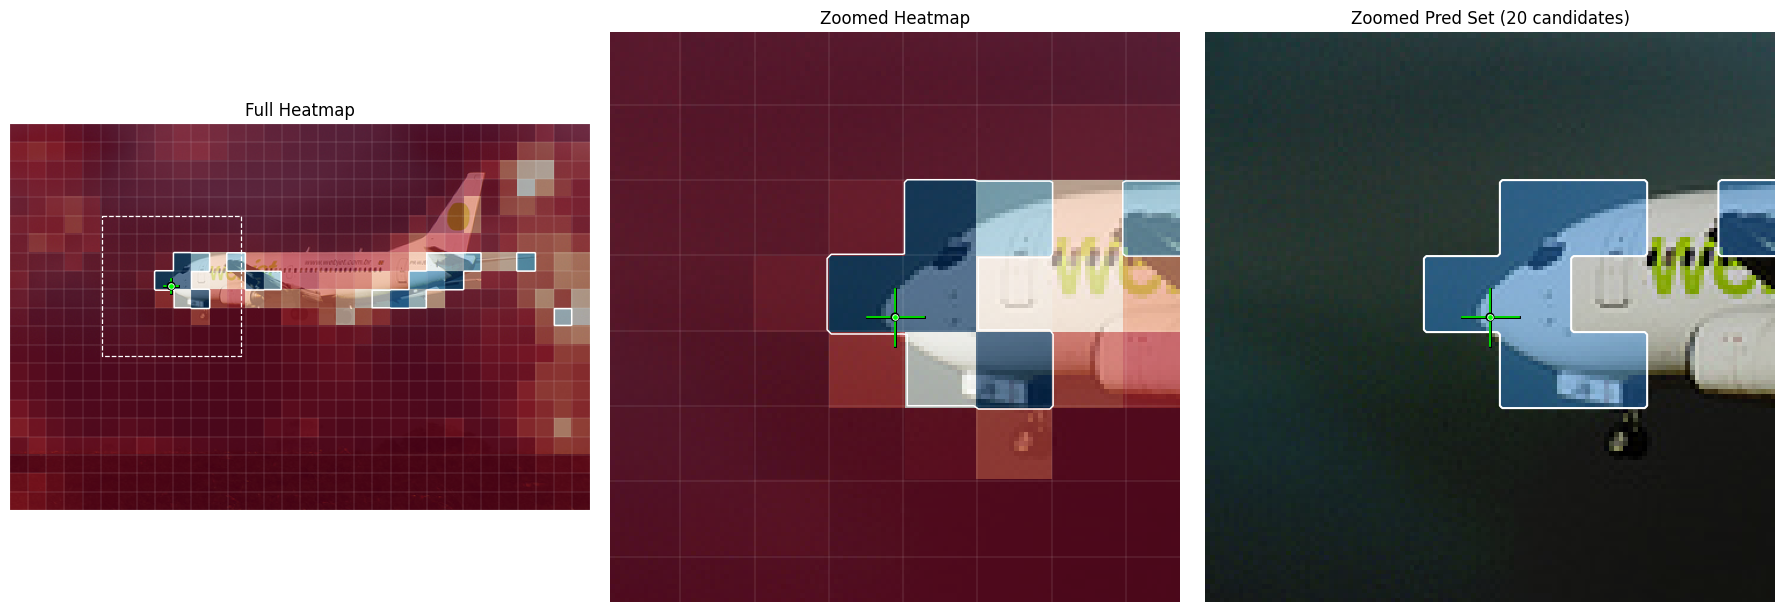

In [96]:
ZOOM_HALF = 60  # pixels around landmark to zoom into

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Full heatmap
_show_heatmap(axes[0], img, scores_2d, "RdBu", 0.65, qhat, lm_xy=lm,
              show_patch_grid=(LEVEL == "patch"))
_draw_zoom_box(axes[0], lm, ZOOM_HALF, h, w)  # show where we zoom
axes[0].set_title("Full Heatmap")

# Zoomed heatmap
_show_heatmap(axes[1], img, scores_2d, "RdBu", 0.65, qhat, lm_xy=lm,
              show_patch_grid=(LEVEL == "patch"))
_apply_zoom(axes[1], lm, ZOOM_HALF, h, w)
axes[1].set_title("Zoomed Heatmap")

# Zoomed prediction set
_show_predset(axes[2], img, mask_2d, color=(0.2, 0.6, 1.0),
              fill_alpha=0.4, lm_xy=lm)
_apply_zoom(axes[2], lm, ZOOM_HALF, h, w)
axes[2].set_title(f"Zoomed Pred Set ({mask_2d.sum()} candidates)")

plt.tight_layout()
plt.show()